============================== -> 第一次运行结果 <- ==============================
{'input_texts': ['  LangGraph 真有意思 ', '  我喜欢 LangChain '], 'output_texts': ['LangGraph 真有意思', '我喜欢 LangChain']}
============================== -> 第二次运行结果 <- ==============================
{'input_texts': ['  Hello, LangGraph  ', '  Hello, LangChain '], 'output_texts': ['LangGraph 真有意思', '我喜欢 LangChain', 'LangGraph 真有意思', 'Hello, LangGraph', '我喜欢 LangChain', 'Hello, LangChain']}


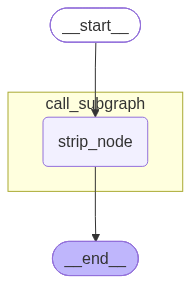

In [2]:
from typing import TypedDict, Annotated
from operator import add
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver

# 构建子图
class SubgraphState(TypedDict):
    raw_text: str
    clean_texts: Annotated[list[str], add]

def strip_node(state: SubgraphState) -> SubgraphState:
    raw_text = state["raw_text"]
    clean_text = raw_text.strip()

    return {
        "clean_texts": [clean_text]
    }

builder = StateGraph(state_schema=SubgraphState)
builder.add_node("strip_node", strip_node)
builder.add_edge(START, "strip_node")
builder.add_edge("strip_node", END)

# ==================================================
# 【策略切换点】只需修改这一行
# subgraph = builder.compile(checkpointer=False)  # Stateless：无检查点
subgraph = builder.compile(checkpointer=True)   # Per-thread：有状态（对比用）
# ==================================================

# 构建父图
class ParentState(TypedDict):
    input_texts: list[str]
    output_texts: Annotated[list[str], add]

def call_subgraph(state: ParentState) -> ParentState:
    input_texts = state["input_texts"]

    output_texts = []
    for input_text in input_texts:
        res = subgraph.invoke({"raw_text": input_text})
        output_texts += res["clean_texts"]

    return {
        "output_texts": output_texts
    }

builder = StateGraph(state_schema=ParentState)
builder.add_node("call_subgraph", call_subgraph)
builder.add_edge(START, "call_subgraph")
builder.add_edge("call_subgraph", END)

checkpointer = InMemorySaver()
parent_graph = builder.compile(checkpointer=checkpointer)

config = {"configurable": {"thread_id": "stateless-demo"}}

first_response = parent_graph.invoke(
    {
        "input_texts": ["  LangGraph 真有意思 ", "  我喜欢 LangChain "]
    },
    config = config
)
print("=" * 30, "-> 第一次运行结果 <-", "=" * 30)
print(first_response)

second_response = parent_graph.invoke(
    {
        "input_texts": ["  Hello, LangGraph  ", "  Hello, LangChain "]
    },
    config = config
)
print("=" * 30, "-> 第二次运行结果 <-", "=" * 30)
print(second_response)

from IPython.display import display, Image
display(
    Image(
        parent_graph
        .get_graph(xray=True)
        .draw_mermaid_png()
    )
)

# 多次调用子图，出现问题